# Lesson 14.1 - Neurosymbolic AI & Causal Reasoning (toy DAG & rule demo)

This notebook demonstrates two practical frontier concepts:

1. A small causal DAG with intervention-style simulation.
2. Symbolic constraints layered on top of probabilistic predictions.
        


## Objectives

- Build and visualize a toy causal graph.
- Compare observational correlation with intervention-driven effects.
- Apply simple rule constraints to model outputs (neurosymbolic pattern).
        


In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

np.random.seed(42)
        


## Build a Toy Causal Graph


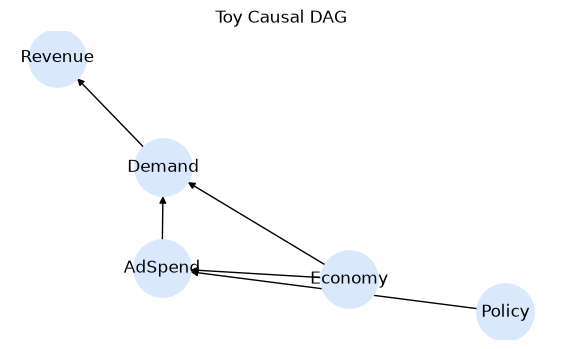

In [2]:
G = nx.DiGraph()
G.add_edges_from(
    [
        ("Policy", "AdSpend"),
        ("Economy", "AdSpend"),
        ("Economy", "Demand"),
        ("AdSpend", "Demand"),
        ("Demand", "Revenue"),
    ]
)

plt.figure(figsize=(7, 4))
pos = nx.spring_layout(G, seed=7)
nx.draw_networkx(G, pos=pos, node_color="#d9e8fb", node_size=1700, arrows=True)
plt.title("Toy Causal DAG")
plt.axis("off")
plt.show()
        


## Simulate Observational Data with Confounding

`Economy` affects both ad spend and demand. If we ignore this confounder, the estimated effect of ad spend can be biased.
        


In [3]:
n = 3000
economy = np.random.normal(0, 1, n)
policy = np.random.binomial(1, 0.45, n)
noise_a = np.random.normal(0, 0.8, n)
noise_d = np.random.normal(0, 0.8, n)

ad_spend = 2.0 * policy + 1.6 * economy + noise_a

demand = 1.8 * ad_spend + 2.2 * economy + noise_d
revenue = 3.0 * demand + np.random.normal(0, 1.2, n)

obs = pd.DataFrame(
    {
        "Policy": policy,
        "Economy": economy,
        "AdSpend": ad_spend,
        "Demand": demand,
        "Revenue": revenue,
    }
)

obs.head()
        


,Policy,Economy,AdSpend,Demand,Revenue
0,1,0.496714,2.642550,6.551399,19.382203
1,1,-0.138264,0.580820,1.022624,3.846849
2,0,0.647689,2.126885,5.708223,16.580758
3,1,1.523030,4.193947,11.206107,35.680450
4,0,-0.234153,-0.765754,-0.592351,-3.324663


In [4]:
corr = obs[["AdSpend", "Demand", "Economy"]].corr()
corr
        


,AdSpend,Demand,Economy
AdSpend,1.000000,0.958737,0.771319
Demand,0.958737,1.000000,0.897347
Economy,0.771319,0.897347,1.000000


## Intervention Simulation: `do(AdSpend = x)`


In [5]:
def simulate_do_intervention(x_value: float, n_samples: int = 5000, seed: int = 0):
    rng = np.random.default_rng(seed)
    economy_i = rng.normal(0, 1, n_samples)

    ad_i = np.full(n_samples, x_value)  # intervention cuts incoming causes
    demand_i = 1.8 * ad_i + 2.2 * economy_i + rng.normal(0, 0.8, n_samples)
    revenue_i = 3.0 * demand_i + rng.normal(0, 1.2, n_samples)
    return float(demand_i.mean()), float(revenue_i.mean())

levels = np.linspace(obs["AdSpend"].quantile(0.1), obs["AdSpend"].quantile(0.9), 9)
rows = []
for x in levels:
    d_mean, r_mean = simulate_do_intervention(float(x), seed=42)
    rows.append({"do_AdSpend": float(x), "E[Demand|do]": d_mean, "E[Revenue|do]": r_mean})

intervention_df = pd.DataFrame(rows)
intervention_df
        


,do_AdSpend,E[Demand|do],E[Revenue|do]
0,-1.689122,-3.084648,-9.264424
1,-1.033667,-1.904828,-5.724965
2,-0.378211,-0.725008,-2.185506
3,0.277244,0.454811,1.353953
4,0.932699,1.634631,4.893412
5,1.588155,2.814451,8.432871
6,2.243610,3.994270,11.972330
7,2.899065,5.174090,15.511789
8,3.554521,6.353910,19.051248


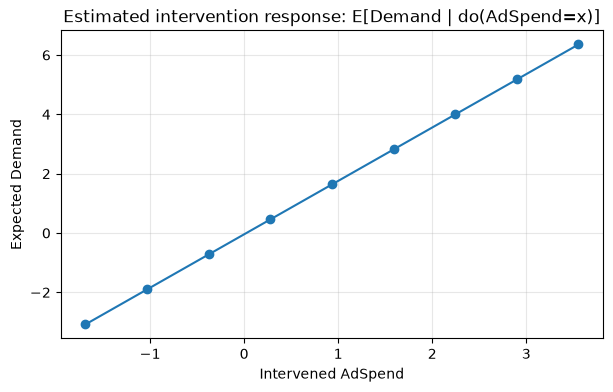

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(intervention_df["do_AdSpend"], intervention_df["E[Demand|do]"], marker="o")
plt.title("Estimated intervention response: E[Demand | do(AdSpend=x)]")
plt.xlabel("Intervened AdSpend")
plt.ylabel("Expected Demand")
plt.grid(alpha=0.3)
plt.show()
        


## Neurosymbolic Rule Layer on Top of a Predictor


In [7]:
# Toy neural-like score (here just a simple handcrafted predictor output)
def predicted_discount_score(row):
    return 0.4 * row["Demand"] - 0.2 * row["Economy"] + 0.3 * row["Policy"]

sample = obs.sample(8, random_state=1).copy()
sample["raw_score"] = sample.apply(predicted_discount_score, axis=1)

# Symbolic constraints (hard policy rules)
# Rule 1: if Economy < -1.5, cap score at 0.2 (risk management)
# Rule 2: if Policy == 0 and Demand < median, force score >= 0 (no negative promotions)
median_demand = float(obs["Demand"].median())

def apply_rules(row):
    score = row["raw_score"]
    if row["Economy"] < -1.5:
        score = min(score, 0.2)
    if row["Policy"] == 0 and row["Demand"] < median_demand:
        score = max(score, 0.0)
    return score

sample["rule_adjusted_score"] = sample.apply(apply_rules, axis=1)
sample[["Policy", "Economy", "Demand", "raw_score", "rule_adjusted_score"]]
        


,Policy,Economy,Demand,raw_score,rule_adjusted_score
1957,0,3.137749,16.249589,5.872286,5.872286
2087,0,-0.147780,-0.700819,-0.250771,0.000000
1394,1,-0.365322,4.615312,2.219189,2.219189
1520,0,1.221034,6.898044,2.515011,2.515011
1098,0,0.916328,4.335622,1.550983,1.550983
393,0,1.831459,9.061815,3.258434,3.258434
28,0,-0.600639,-1.643811,-0.537397,0.000000
99,0,-0.234587,-3.152781,-1.214195,0.000000


## Connect to Theory

- The DAG and `do` simulation illustrate intervention reasoning.
- The rule layer shows a simple neurosymbolic architecture where learned signals are constrained by explicit domain logic.
- In production, this pattern maps to policy constraints, compliance checks, and safety gates.
        


## Frontier Case Studies & Exceptions

### Case Study A: Policy Analytics
A growth team replaced correlational uplift analysis with intervention-based simulation and changed rollout order, reducing downside risk.

### Case Study B: Constraint-Aware Assistant
A decision assistant used LLM outputs plus explicit business rules to prevent invalid recommendations.

### Exceptions
If interventions are impossible to define or domain assumptions are weak, causal claims should be framed as hypotheses, not certainties.
        


## Interview Questions & Answers

1. **Q:** What is neurosymbolic AI?  
   **A:** Hybrid AI combining learned representations with explicit symbolic reasoning or constraints.
2. **Q:** Why use a DAG in ML discussions?  
   **A:** It makes causal assumptions explicit and supports intervention reasoning.
3. **Q:** Correlation vs intervention?  
   **A:** Correlation describes association; intervention estimates effect of deliberate change.
4. **Q:** What does `do(x)` mean?  
   **A:** Force variable x to a value, breaking natural causes.
5. **Q:** Why add symbolic constraints?  
   **A:** To enforce hard rules and reduce invalid behavior.
6. **Q:** What is a confounder?  
   **A:** A variable influencing both cause and outcome, biasing naive estimates.
7. **Q:** Practical causal first step?  
   **A:** Frame business question as an intervention question.
8. **Q:** When is NeSy useful?  
   **A:** Structured tasks with domain rules and high reliability requirements.
9. **Q:** One risk of causal modeling?  
   **A:** Overconfidence from untested assumptions.
10. **Q:** One risk of symbolic rules?  
    **A:** Maintenance burden when policies evolve quickly.
11. **Q:** How does this improve safety?  
    **A:** It reduces shortcut dependence and enforces policy-consistent outputs.
        
